# প্রকল্প ০৫: বিদ্যুৎ ব্যবহার পূর্বাভাস
## ⚡ আরিমা + এসভিআর

### 🎪 গল্প দিয়ে শুরু করি

**মনে করো,** তুমি একটি পাওয়ার কোম্পানিতে কাজ করো। বিদ্যুৎ উৎপাদন করতে খরচ হয় — বেশি উৎপাদন করলে অপচয়, কম করলে ব্ল্যাকআউট!

তাই তুমি জানতে চাও — **আগামীকাল কত বিদ্যুৎ লাগবে?**

গত এক বছর ধরে প্রতিদিন কত বিদ্যুৎ ব্যবহার হয়েছে, তার ডেটা তোমার কাছে আছে:
- জানুয়ারিতে বেশি লাগে (গরমের জন্য)
- ডিসেম্বরে কম লাগে
- সপ্তাহের নির্দিষ্ট দিনে প্যাটার্ন থাকে

**এটাই টাইম সিরিজ ফোরকাস্টিং!** আমরা সময়ের সাথে ডেটার প্যাটার্ন খুঁজে বের করে ভবিষ্যৎ বলবো।

In [1]:
# লাইব্রেরি ইম্পোর্ট
import pandas as pd  # ডেটা হ্যান্ডলিং
import numpy as np  # গণিত
import matplotlib.pyplot as plt  # গ্রাফ
from sklearn.model_selection import train_test_split  # ডেটা ভাগ
from sklearn.svm import SVR  # এসভিআর (Support Vector Regression)
from sklearn.preprocessing import StandardScaler  # স্কেলিং
from sklearn.metrics import mean_squared_error  # মূল্যায়ন
from statsmodels.tsa.arima.model import ARIMA  # আরিমা মডেল
import warnings
warnings.filterwarnings('ignore')  # ওয়ার্নিং বন্ধ

# ডেটা লোড
df = pd.read_csv('power_usage.csv')
print('ডেটার প্রথম ৫ সারি:')
display(df.head())
print(f'\nমোট দিন: {len(df)}')


ডেটার প্রথম ৫ সারি:


,date,usage
0,2022-01-01,72.5
1,2022-01-02,69.7
2,2022-01-03,104.3
3,2022-01-04,109.2
4,2022-01-05,100.9



মোট দিন: 730


ডেটার সময়সীমা:
শুরু: 2022-01-01 00:00:00
শেষ: 2023-12-31 00:00:00


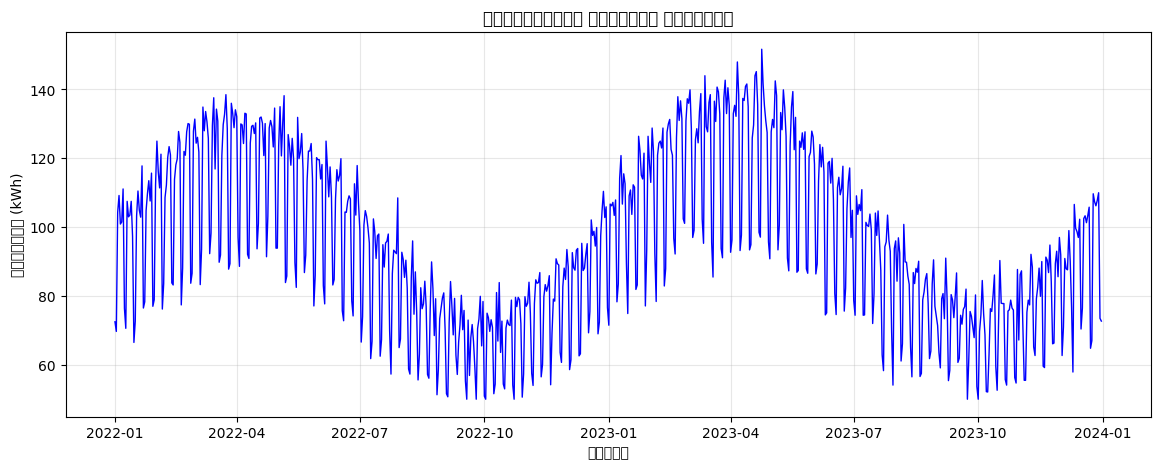

In [2]:
# ডেটা প্রস্তুতি
df['date'] = pd.to_datetime(df['date'])  # তারিখকে ডেটটাইমে রূপান্তর
df = df.sort_values('date').reset_index(drop=True)  # তারিখ অনুযায়ী সাজানো

print('ডেটার সময়সীমা:')
print(f'শুরু: {df["date"].min()}')
print(f'শেষ: {df["date"].max()}')

plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['usage'], color='blue', linewidth=1)
plt.title('প্রতিদিনের বিদ্যুৎ ব্যবহার')
plt.xlabel('তারিখ')
plt.ylabel('ব্যবহার (kWh)')
plt.grid(True, alpha=0.3)
plt.show()

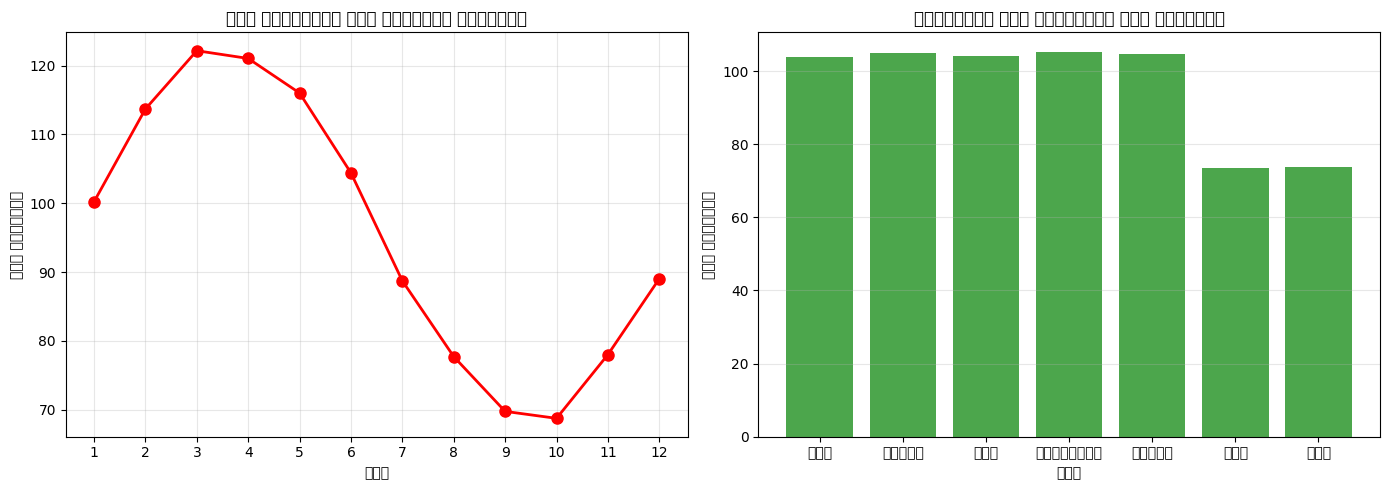

In [3]:
# ইডিএ — প্যাটার্ন দেখা যাক
df['month'] = df['date'].dt.month  # মাস বের করা
df['day_of_week'] = df['date'].dt.dayofweek  # সপ্তাহের দিন

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
monthly = df.groupby('month')['usage'].mean()
plt.plot(monthly.index, monthly.values, 'ro-', linewidth=2, markersize=8)
plt.title('মাস অনুযায়ী গড় বিদ্যুৎ ব্যবহার')
plt.xlabel('মাস')
plt.ylabel('গড় ব্যবহার')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
weekly = df.groupby('day_of_week')['usage'].mean()
days = ['সোম', 'মঙ্গল', 'বুধ', 'বৃহস্পতি', 'শুক্র', 'শনি', 'রবি']
plt.bar(weekly.index, weekly.values, color='green', alpha=0.7)
plt.title('সপ্তাহের দিন অনুযায়ী গড় ব্যবহার')
plt.xlabel('দিন')
plt.ylabel('গড় ব্যবহার')
plt.xticks(range(7), days)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## ⏰ আরিমা মডেল (ARIMA)
ARIMA মানে **A**uto**R**egressive **I**ntegrated **M**oving **A**verage.

আরিমা টাইম সিরিজের তিনটি জিনিস দেখে:
1. **AR (অটোরিগ্রেসিভ):** আগের মানের উপর নির্ভরশীলতা
2. **I (ইন্টিগ্রেটেড):** ডেটাকে স্থির করার জন্য ডিফারেন্সিং
3. **MA (মুভিং এভারেজ):** আগের ভুলের উপর নির্ভরশীলতা

In [4]:
# আরিমা মডেলের জন্য ডেটা প্রস্তুতি
usage_series = df['usage'].values  # টাইম সিরিজ ডেটা

# ট্রেন-টেস্ট ভাগ (শেষ ৩০ দিন টেস্ট)
train_size = len(usage_series) - 30
train, test = usage_series[:train_size], usage_series[train_size:]

print(f'ট্রেন ডেটা: {len(train)} দিন')
print(f'টেস্ট ডেটা: {len(test)} দিন')

ট্রেন ডেটা: 700 দিন
টেস্ট ডেটা: 30 দিন


In [5]:
# আরিমা মডেল তৈরি ও শেখানো
arima_model = ARIMA(train, order=(5, 1, 2))  # (p=5, d=1, q=2)
arima_fitted = arima_model.fit()

print(arima_fitted.summary())

# পূর্বাভাস
arima_pred = arima_fitted.forecast(steps=len(test))

# মূল্যায়ন
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
print(f'\n📊 আরিমা মডেলের RMSE: {arima_rmse:.2f}')

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  700
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -2418.155
Date:                Sat, 23 May 2026   AIC                           4852.311
Time:                        14:15:42   BIC                           4888.708
Sample:                             0   HQIC                          4866.381
                                - 700                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0804      0.033      2.426      0.015       0.015       0.145
ar.L2         -0.7935      0.025    -32.111      0.000      -0.842      -0.745
ar.L3         -0.2760      0.038     -7.238      0.0

## 📈 এসভিআর (Support Vector Regression)
এসভিআর হলো SVM এর রিগ্রেশন ভার্সন। এটি জটিল সম্পর্ক খুঁজে বের করতে পারে!

আমরা এসভিআর-এর জন্য আগের কিছু দিনের মান ফিচার হিসেবে দেবো।

In [6]:
# এসভিআর-এর জন্য ফিচার তৈরি
def create_features(series, lookback=7):
    # আগের lookback দিনের মান ফিচার হিসেবে তৈরি
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])  # আগের ৭ দিন
        y.append(series[i])  # আজকের মান
    return np.array(X), np.array(y)

lookback = 7
X, y = create_features(usage_series, lookback)

print(f'ফিচার শেপ: {X.shape}')
print(f'প্রথম স্যাম্পল (আগের ৭ দিন): {X[0].round(1)}')
print(f'টার্গেট (৮ম দিন): {y[0]:.1f}')

ফিচার শেপ: (723, 7)
প্রথম স্যাম্পল (আগের ৭ দিন): [ 72.5  69.7 104.3 109.2 100.9 101.5 111.1]
টার্গেট (৮ম দিন): 76.4


In [7]:
# এসভিআর-এর জন্য ট্রেন-টেস্ট ভাগ
X_train, X_test_svr, y_train, y_test_svr = train_test_split(X, y, test_size=0.15, random_state=42, shuffle=False)

# ডেটা স্কেলিং
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test_svr)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

# এসভিআর মডেল
svr_model = SVR(kernel='rbf', C=100, gamma='scale')  # RBF কার্নেল
svr_model.fit(X_train_s, y_train_s)

# পূর্বাভাস ও স্কেল ফিরিয়ে আনা
svr_pred_s = svr_model.predict(X_test_s)
svr_pred = scaler_y.inverse_transform(svr_pred_s.reshape(-1, 1)).ravel()

# মূল্যায়ন
svr_rmse = np.sqrt(mean_squared_error(y_test_svr, svr_pred))
print(f'📊 এসভিআর মডেলের RMSE: {svr_rmse:.2f}')

📊 এসভিআর মডেলের RMSE: 7.66


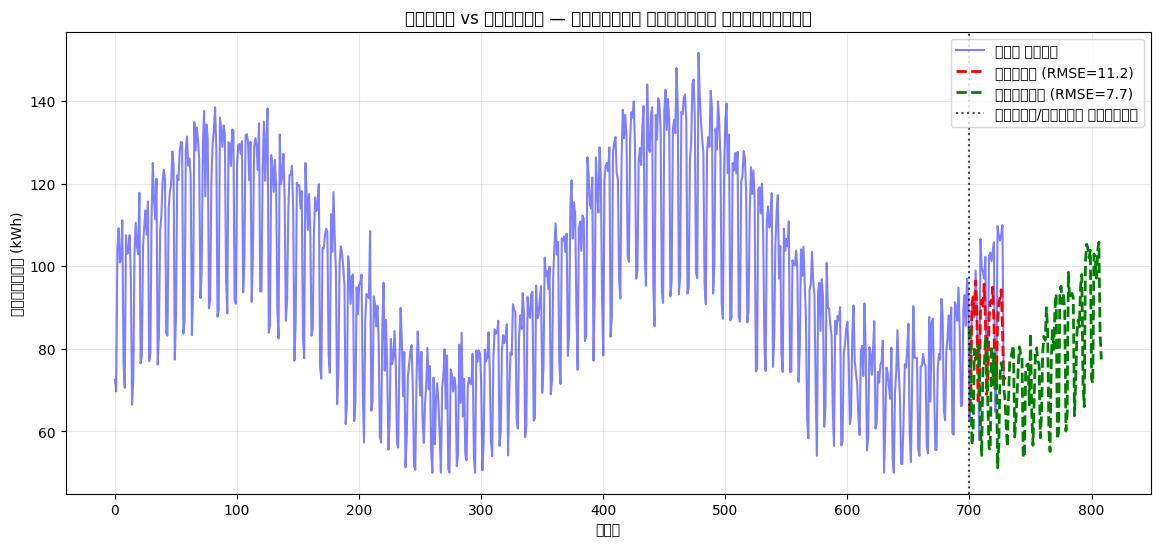

In [8]:
# আরিমা এবং এসভিআরের তুলনা
plt.figure(figsize=(14, 6))

# পুরো ডেটা
plt.plot(range(len(usage_series)), usage_series, 'b-', alpha=0.5, label='আসল ডেটা')

# আরিমা পূর্বাভাস
arima_x = range(train_size, train_size + len(arima_pred))
plt.plot(arima_x, arima_pred, 'r--', linewidth=2, label=f'আরিমা (RMSE={arima_rmse:.1f})')

# এসভিআর পূর্বাভাস (অ্যালাইন করার জন্য)
svr_x = range(train_size, train_size + len(svr_pred))
plt.plot(svr_x, svr_pred, 'g--', linewidth=2, label=f'এসভিআর (RMSE={svr_rmse:.1f})')

plt.axvline(x=train_size, color='black', linestyle=':', alpha=0.7, label='ট্রেন/টেস্ট সীমানা')
plt.title('আরিমা vs এসভিআর — বিদ্যুৎ ব্যবহার পূর্বাভাস')
plt.xlabel('দিন')
plt.ylabel('ব্যবহার (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1200x500 with 0 Axes>

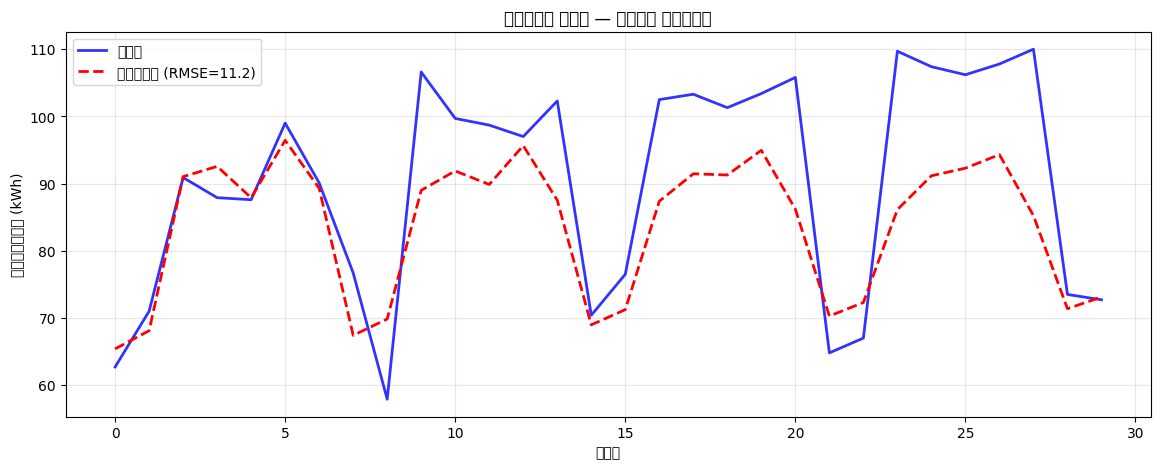

In [9]:
# শুধু টেস্ট সেটের জুম করা দৃশ্য
plt.figure(figsize=(12, 5))
test_indices = list(range(len(test)))
plt.plot(test_indices, test, 'b-', linewidth=2, label='আসল')
plt.plot(test_indices, arima_pred, 'r--', linewidth=2, label='আরিমা')

# এসভিআর টেস্ট সেট
svr_test_start = len(y_train)
svr_test_indices = list(range(len(y_test_svr)))
plt.plot(svr_test_indices[len(svr_test_indices)-len(svr_pred):], svr_pred, 'g--', linewidth=2, label='এসভিআর')

# Actually let's fix the SVR alignment
plt.clf()
plt.figure(figsize=(14, 5))

# পুরো টেস্ট পিরিয়ড
plt.plot(test, 'b-', linewidth=2, label='আসল', alpha=0.8)
plt.plot(arima_pred, 'r--', linewidth=2, label=f'আরিমা (RMSE={arima_rmse:.1f})')

if len(svr_pred) <= len(test):
    svr_plot = np.full(len(test), np.nan)
    svr_plot[-len(svr_pred):] = svr_pred
    plt.plot(svr_plot, 'g--', linewidth=2, label=f'এসভিআর (RMSE={svr_rmse:.1f})')

plt.title('টেস্ট সেট — মডেল তুলনা')
plt.xlabel('দিন')
plt.ylabel('ব্যবহার (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

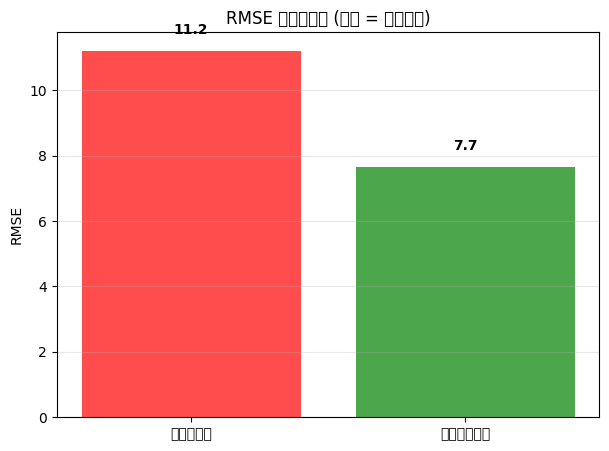


🏆 সেরা মডেল: এসভিআর (RMSE = 7.7)

📌 মনে রাখবে: RMSE যত কম, মডেল তত নির্ভুল!


In [10]:
# চূড়ান্ত তুলনা
models = ['আরিমা', 'এসভিআর']
rmses = [arima_rmse, svr_rmse]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, rmses, color=['red', 'green'], alpha=0.7)
plt.title('RMSE তুলনা (কম = ভালো)')
plt.ylabel('RMSE')
for bar, rmse in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rmse:.1f}', ha='center', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

best_model = 'আরিমা' if arima_rmse < svr_rmse else 'এসভিআর'
print(f'\n🏆 সেরা মডেল: {best_model} (RMSE = {min(rmses):.1f})')
print(f'\n📌 মনে রাখবে: RMSE যত কম, মডেল তত নির্ভুল!')

## 🎯 তুমি কি শিখলে?

| ধারণা | বাংলায় অর্থ |
|-------|-------------|
| **টাইম সিরিজ** | সময় অনুযায়ী সাজানো ডেটা |
| **আরিমা (ARIMA)** | টাইম সিরিজের জন্য বিশেষ মডেল (প্যাটার্ন খোঁজে) |
| **এসভিআর (SVR)** | জটিল সম্পর্ক খুঁজে বের করতে পারে এমন রিগ্রেশন |
| **RMSE** | মডেলের ভুলের পরিমাণ (কম = ভালো) |
| **ফোরকাস্টিং** | ভবিষ্যতের মান অনুমান করা |
| **লুকব্যাক** | পূর্বাভাসের জন্য আগের কত দিনের ডেটা দরকার |

**মনে রাখবে:** টাইম সিরিজ ফোরকাস্টিং ব্যবসায় খুবই গুরুত্বপূর্ণ — স্টক মার্কেট, আবহাওয়া, বিদ্যুৎ চাহিদা সবকিছুতেই ব্যবহার হয়! সময়ের সাথে ডেটার প্যাটার্ন বুঝতে পারলেই ভবিষ্যৎ বলা সম্ভব! ⚡